# Language Modelling.


### 1. Character-Level LSTM.

As an example, I will train only on shakespeare sonnets (same as last year). This network is based off of Andrej Karpathy's [post on RNNs](http://karpathy.github.io/2015/05/21/rnn-effectiveness/).

In [1]:
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
import os
import requests

#### Load in Data

In [2]:
# with open('https://caltech-cs155.s3.us-east-2.amazonaws.com/miniprojects/project3/data/shakespeare.txt', 'r') as f:
#     text = f.read()

input_file_path = 'data/shakespeare.txt'
if not os.path.exists(input_file_path):
    data_url = 'https://caltech-cs155.s3.us-east-2.amazonaws.com/miniprojects/project3/data/shakespeare.txt'
    # Create the directory if it doesn't exist
    os.makedirs(os.path.dirname(input_file_path), exist_ok=True)
    with open(input_file_path, 'w', encoding='utf-8') as f:
        f.write(requests.get(data_url).text)

with open(input_file_path, 'r', encoding='utf-8') as f:
    text = f.read()
# text[:100]

### Tokenization.

In [3]:
chars = tuple(set(text))
itos = dict(enumerate(chars)) # maps integers to characters
stoi = {ch: ii for ii, ch in itos.items()} # maps characters to unique integers
vocab_size = len(chars)

encoded = np.array([stoi[ch] for ch in text])

n = len(encoded)
split_idx = int(n * 0.9)
train_data = encoded[:split_idx]
val_data = encoded[split_idx:]

print(f"Dataset size:  {len(text):,} characters")
print(f"Vocab size:    {vocab_size}")
print(f"Train:         {len(train_data):,} tokens ({len(train_data)/n:.0%})")
print(f"Val:           {len(val_data):,} tokens ({len(val_data)/n:.0%})")
print(f"Characters:    {repr(''.join(sorted(chars)))}")

Dataset size:  98,029 characters
Vocab size:    71
Train:         88,226 tokens (90%)
Val:           9,803 tokens (10%)
Characters:    "\n !'(),-.0123456789:;?ABCDEFGHIJKLMNOPRSTUVWYabcdefghijklmnopqrstuvwxyz"


#### Pre-processing


In [4]:
test_seq = np.array([[3, 5, 1]])
one_hot = F.one_hot(torch.tensor(test_seq), num_classes=8)

print(one_hot)

tensor([[[0, 0, 0, 1, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 1, 0, 0],
         [0, 1, 0, 0, 0, 0, 0, 0]]])


#### Minibatches

In [5]:
def get_batches(arr, batch_size, seq_length):
    '''Create a generator that returns batches of size
       batch_size x seq_length from arr.
       
       Arguments
       ---------
       arr: Array you want to make batches from
       batch_size: Batch size, the number of sequences per batch
       seq_length: Number of encoded chars in a sequence
    '''
    
    batch_size_total = batch_size * seq_length
    # total number of batches we can make
    n_batches = len(arr)//batch_size_total
    
    # Keep only enough characters to make full batches
    arr = arr[:n_batches * batch_size_total]
    # Reshape into batch_size rows
    arr = arr.reshape((batch_size, -1))
    
    for n in range(0, arr.shape[1], seq_length):
        # The features
        x = arr[:, n:n+seq_length]
        # The targets, shifted by one
        y = np.zeros_like(x)
        try:
            y[:, :-1], y[:, -1] = x[:, 1:], arr[:, n+seq_length]
        except IndexError:
            y[:, :-1], y[:, -1] = x[:, 1:], arr[:, 0]
        yield x, y

In [6]:
batches = get_batches(encoded, 8, 50)
x, y = next(batches)

# print('x\n', x[:10, :10])
# print('\ny\n', y[:10, :10])

#### Model

In [7]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Training on: {DEVICE}')

Training on: cuda


In [8]:
class CharLSTM(nn.Module):
    
    def __init__(self, tokens, n_hidden=256, n_layers=2,
                               drop_prob=0.5, lr=0.001):
        super().__init__()
        self.drop_prob = drop_prob
        self.n_layers = n_layers
        self.n_hidden = n_hidden
        self.lr = lr
        
        self.chars = tokens
        self.itos = dict(enumerate(self.chars))
        self.stoi = {ch: ii for ii, ch in self.itos.items()}
        
        self.lstm = nn.LSTM(len(self.chars), n_hidden, n_layers, 
                            dropout=drop_prob, batch_first=True)
        
        self.dropout = nn.Dropout(drop_prob)
        self.fc = nn.Linear(n_hidden, len(self.chars))
      
    
    def forward(self, x, hidden):
        ''' Forward pass through the network. 
            These inputs are x, and the hidden/cell state `hidden`. '''
                
        r_output, hidden = self.lstm(x, hidden)
        out = self.dropout(r_output)
        out = out.contiguous().view(-1, self.n_hidden)
        out = self.fc(out)
    
        return out, hidden
    
    
    def init_hidden(self, batch_size):
        ''' Initializes hidden state '''
        weight = next(self.parameters()).data
        hidden = (weight.new(self.n_layers, batch_size, self.n_hidden).zero_().to(DEVICE),
                  weight.new(self.n_layers, batch_size, self.n_hidden).zero_().to(DEVICE))
        return hidden
        

#### train fn


In [9]:
def train(net, train_data, val_data, epochs=10, batch_size=10, seq_length=50, lr=0.001, clip=5, print_every=10):
    net.train()
    
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    net.to(DEVICE)
    
    counter = 0
    n_chars = len(net.chars)
    
    train_loss_history = []
    val_loss_history = []
    steps = []
    
    for e in range(epochs):
        h = net.init_hidden(batch_size)
        
        for x, y in get_batches(train_data, batch_size, seq_length):
            counter += 1
            
            inputs = F.one_hot(torch.tensor(x), num_classes=n_chars).float().to(DEVICE)
            targets = torch.tensor(y).to(DEVICE)
            
            h = tuple([each.data for each in h])

            net.zero_grad()
            
            output, h = net(inputs, h)
            
            loss = criterion(output, targets.view(batch_size*seq_length).long())
            loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(), clip)
            opt.step()
            
            if counter % print_every == 0:
                val_h = net.init_hidden(batch_size)
                val_losses = []
                net.eval()
                for x, y in get_batches(val_data, batch_size, seq_length):
                    inputs = F.one_hot(torch.tensor(x), num_classes=n_chars).float().to(DEVICE)
                    targets = torch.tensor(y).to(DEVICE)
                    
                    val_h = tuple([each.data for each in val_h])

                    output, val_h = net(inputs, val_h)
                    val_loss = criterion(output, targets.view(batch_size*seq_length).long())
                
                    val_losses.append(val_loss.item())
                
                net.train()
                
                avg_val_loss = np.mean(val_losses)
                train_loss_history.append(loss.item())
                val_loss_history.append(avg_val_loss)
                steps.append(counter)
                
                print("Epoch: {}/{}...".format(e+1, epochs),
                      "Step: {}...".format(counter),
                      "Loss: {:.4f}...".format(loss.item()),
                      "Val Loss: {:.4f}".format(avg_val_loss))
    
    return steps, train_loss_history, val_loss_history

#### Instantiate the model

In [10]:
# define and print the net
n_hidden=512
n_layers=3

net = CharLSTM(chars, n_hidden, n_layers)
print(net)

CharLSTM(
  (lstm): LSTM(71, 512, num_layers=3, batch_first=True, dropout=0.5)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=71, bias=True)
)


In [11]:
batch_size = 128
seq_length = 100
n_epochs = 20 

steps, train_losses, val_losses = train(net, train_data, val_data, epochs=n_epochs, batch_size=batch_size, seq_length=seq_length, lr=0.001, print_every=10)

/home/dirakiza/miniconda3/envs/lstm-env/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/dirakiza/miniconda3/envs/lstm-env/lib/python3.14/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Epoch: 2/20... Step: 10... Loss: 3.2060... Val Loss: nan
Epoch: 4/20... Step: 20... Loss: 3.1156... Val Loss: nan
Epoch: 5/20... Step: 30... Loss: 3.0922... Val Loss: nan
Epoch: 7/20... Step: 40... Loss: 3.0826... Val Loss: nan
Epoch: 9/20... Step: 50... Loss: 3.0822... Val Loss: nan
Epoch: 10/20... Step: 60... Loss: 3.0804... Val Loss: nan
Epoch: 12/20... Step: 70... Loss: 3.0724... Val Loss: nan
Epoch: 14/20... Step: 80... Loss: 3.1941... Val Loss: nan
Epoch: 15/20... Step: 90... Loss: 3.0891... Val Loss: nan
Epoch: 17/20... Step: 100... Loss: 3.0785... Val Loss: nan
Epoch: 19/20... Step: 110... Loss: 3.0770... Val Loss: nan
Epoch: 20/20... Step: 120... Loss: 3.0719... Val Loss: nan


#### Train vs Val Loss

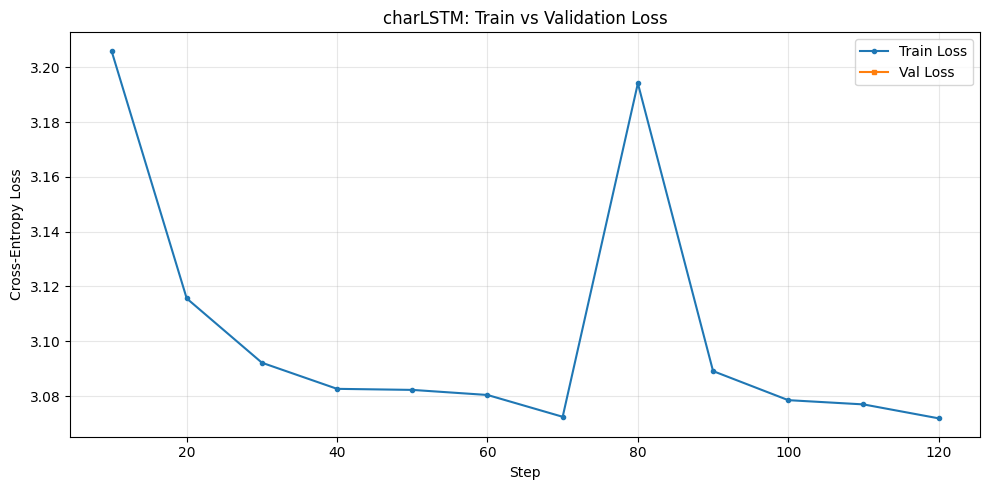

Final train loss: 3.0719
Final val loss:   nan
Gap (val - train): nan


In [12]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(10, 5))
plt.plot(steps, train_losses, label='Train Loss', marker='o', markersize=3)
plt.plot(steps, val_losses, label='Val Loss', marker='s', markersize=3)
plt.xlabel('Step')
plt.ylabel('Cross-Entropy Loss')
plt.title('charLSTM: Train vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

gap = val_losses[-1] - train_losses[-1]
print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Final val loss:   {val_losses[-1]:.4f}")
print(f"Gap (val - train): {gap:.4f}")

#### making predictions


In [15]:
def predict(net, char, h=None, top_k=None):
        ''' Given a character, predict the next character.
            Returns the predicted character and the hidden state.
        '''
        
        x = torch.tensor([[net.stoi[char]]])
        inputs = F.one_hot(x, num_classes=len(net.chars)).float().to(DEVICE)
        
        h = tuple([each.data for each in h])
        out, h = net(inputs, h)

        p = F.softmax(out, dim=1).data.cpu()
        
        if top_k is None:
            top_ch = np.arange(len(net.chars))
        else:
            p, top_ch = p.topk(top_k)
            top_ch = top_ch.numpy().squeeze()
        
        p = p.numpy().squeeze()
        char = np.random.choice(top_ch, p=p/p.sum())
        
        return net.itos[char], h

### priming and generating text 

Typically you'll want to prime the network so you can build up a hidden state. Otherwise the network will start out generating characters at random. In general the first bunch of characters will be a little rough since it hasn't built up a long history of characters to predict from.

In [16]:
def sample(net, size, prime='The', top_k=None):
        
    net.to(DEVICE)
    net.eval()
    
    # First off, run through the prime characters
    chars = [ch for ch in prime]
    h = net.init_hidden(1)
    for ch in prime:
        char, h = predict(net, ch, h, top_k=top_k)

    chars.append(char)
    
    # Now pass in the previous character and get a new one
    for ii in range(size):
        char, h = predict(net, chars[-1], h, top_k=top_k)
        chars.append(char)

    return ''.join(chars)

In [18]:
print(sample(net, 1000, prime='1', top_k=5))

1x
Thee all my love as forbet was still.
So long translic of such time to shapes a part,
And time thy heart weed's farshe of your self will from the triend,
The sweet for minter, of should belongs to the dose,
The starp to tortues my self and mayst all thee with sheal true,
And therefore as the swart, when I sange a fears of their self doth doth thee with thee tan the waste,
Then more shall not beauty's beauty shadows to the swart beaution form,
She thy same thou walt being mune, or as me feep to secrece, but death die, and there be altory thoughts, and you will such all tho end of mine own shall be disgente.
  So long thy show thy bain a form ansoyer ambast,
Though thou art then my heart to be,
  The world a stame that thou shalt swite to made of thy heart,
And bark thy his swretched.
  And the sweet self are praise, the sweet self the framits of which is that she say as mine own painted beauty days.
O lose the world's self to thee.


                      112
Thy wills thas with that

---

## 2. nanoGPT (Transformer) — Trained from Scratch

Now let's train a standard **Transformer GPT** (à la [Karpathy's nanoGPT](https://github.com/karpathy/nanoGPT)) on the same Shakespeare character-level dataset. This uses multi-head causal self-attention instead of any recurrence, so we can compare the two architectures head-to-head.

We define the full model inline — `CausalSelfAttention → Block → NanoGPT` — and train with the same hyperparameters as before:
- 6 layers, 6 heads, 384-dim embeddings
- 20% dropout, context window of 256 characters
- Cosine LR schedule with warmup

In [9]:
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F

import os
import math
import time
import inspect
from dataclasses import dataclass
from contextlib import nullcontext

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [4]:


class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                     .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        att = self.attn_dropout(att)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y

class GPT_MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x

class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd, bias=config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd, bias=config.bias)
        self.mlp = GPT_MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

@dataclass
class NanoGPTConfig:
    block_size: int = 1024
    vocab_size: int = 50304
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768
    dropout: float = 0.0
    bias: bool = True

class NanoGPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.token_emb = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_emb = nn.Embedding(config.block_size, config.n_embd)
        self.drop = nn.Dropout(config.dropout)
        self.blocks = nn.ModuleList([TransformerBlock(config) for _ in range(config.n_layer)])
        self.ln_f = nn.LayerNorm(config.n_embd, bias=config.bias)
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.token_emb.weight = self.lm_head.weight  # weight tying
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        b, t = idx.size()
        assert t <= self.config.block_size
        pos = torch.arange(0, t, dtype=torch.long, device=idx.device)
        x = self.drop(self.token_emb(idx) + self.pos_emb(pos))
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        if targets is not None:
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        else:
            logits = self.lm_head(x[:, [-1], :])
            loss = None
        return logits, loss

    def get_num_params(self):
        return sum(p.numel() for p in self.parameters())

    def configure_optimizers(self, weight_decay, learning_rate, betas, device_type):
        param_dict = {pn: p for pn, p in self.named_parameters() if p.requires_grad}
        decay_params = [p for n, p in param_dict.items() if p.dim() >= 2]
        nodecay_params = [p for n, p in param_dict.items() if p.dim() < 2]
        optim_groups = [
            {'params': decay_params, 'weight_decay': weight_decay},
            {'params': nodecay_params, 'weight_decay': 0.0}
        ]
        print(f"decay params: {sum(p.numel() for p in decay_params):,} | no-decay params: {sum(p.numel() for p in nodecay_params):,}")
        fused_available = 'fused' in inspect.signature(torch.optim.AdamW).parameters
        use_fused = fused_available and device_type == 'cuda'
        optimizer = torch.optim.AdamW(optim_groups, lr=learning_rate, betas=betas, fused=use_fused)
        return optimizer

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

print("NanoGPT model defined.")

NanoGPT model defined.


#### Prepare data (BPE)

We tokenize the text using **GPT-2's BPE tokenizer** via `tiktoken`. This gives a much larger vocabulary (~50k subword tokens) but produces shorter sequences, which is more efficient for transformers.

In [11]:
# Character-level tokenization

import numpy as np
import torch

# Build vocabulary from dataset
chars = sorted(list(set(text)))
gpt_vocab_size = len(chars)

# Create mappings
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

# Encode / decode functions
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

# Encode entire dataset
encoded = np.array(encode(text), dtype=np.int64)

# Train / validation split
n = len(encoded)
gpt_train_data = encoded[:int(n * 0.9)]
gpt_val_data = encoded[int(n * 0.9):]

print(f"Character vocab size: {vocab_size}")
print(f"Text: {len(text):,} chars → {n:,} tokens (1 char = 1 token)")
print(f"Train: {len(gpt_train_data):,} tokens | Val: {len(gpt_val_data):,} tokens")

Character vocab size: 65
Text: 1,115,393 chars → 1,115,393 tokens (1 char = 1 token)
Train: 1,003,853 tokens | Val: 111,540 tokens


#### Build model and data loader

In [12]:
gpt_block_size = 256
gpt_batch_size = 64

gpt_config = NanoGPTConfig(
    block_size=gpt_block_size,
    vocab_size=gpt_vocab_size,
    n_layer=6,
    n_head=6,
    n_embd=384,
    dropout=0.2,
    bias=False,
)

gpt_model = NanoGPT(gpt_config).to(DEVICE)
print(f"nanoGPT model: {gpt_model.get_num_params():,} parameters")

def gpt_get_batch(split):
    data = gpt_train_data if split == 'train' else gpt_val_data
    ix = torch.randint(len(data) - gpt_block_size, (gpt_batch_size,))
    x = torch.stack([torch.from_numpy(data[i:i+gpt_block_size].copy()) for i in ix])
    y = torch.stack([torch.from_numpy(data[i+1:i+1+gpt_block_size].copy()) for i in ix])
    return x.to(DEVICE), y.to(DEVICE)

nanoGPT model: 10,745,088 parameters


#### Training loop

In [13]:
gpt_learning_rate = 1e-3
gpt_max_iters = 5000
gpt_warmup_iters = 100
gpt_lr_decay_iters = 5000
gpt_min_lr = 1e-4
gpt_eval_interval = 250
gpt_eval_iters = 200
gpt_grad_clip = 1.0
gpt_log_interval = 100

device_type = 'cuda' if 'cuda' in DEVICE else 'cpu'
dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16'
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]
ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)
scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))

gpt_optimizer = gpt_model.configure_optimizers(
    weight_decay=1e-1,
    learning_rate=gpt_learning_rate,
    betas=(0.9, 0.99),
    device_type=device_type,
)

def gpt_get_lr(it):
    if it < gpt_warmup_iters:
        return gpt_learning_rate * it / gpt_warmup_iters
    if it > gpt_lr_decay_iters:
        return gpt_min_lr
    decay_ratio = (it - gpt_warmup_iters) / (gpt_lr_decay_iters - gpt_warmup_iters)
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return gpt_min_lr + coeff * (gpt_learning_rate - gpt_min_lr)

@torch.no_grad()
def gpt_estimate_loss():
    out = {}
    gpt_model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(gpt_eval_iters)
        for k in range(gpt_eval_iters):
            X, Y = gpt_get_batch(split)
            with ctx:
                _, loss = gpt_model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    gpt_model.train()
    return out

decay params: 10,740,096 | no-decay params: 4,992


/tmp/ipykernel_1339307/3433473836.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


In [14]:
torch.manual_seed(1337)

gpt_train_losses = []
gpt_val_losses = []
gpt_eval_steps = []
gpt_best_val_loss = 1e9

gpt_model.train()
t0 = time.time()

for iter_num in range(gpt_max_iters + 1):
    lr = gpt_get_lr(iter_num)
    for param_group in gpt_optimizer.param_groups:
        param_group['lr'] = lr

    if iter_num % gpt_eval_interval == 0:
        losses = gpt_estimate_loss()
        gpt_train_losses.append(losses['train'])
        gpt_val_losses.append(losses['val'])
        gpt_eval_steps.append(iter_num)
        marker = " *" if losses['val'] < gpt_best_val_loss else ""
        if losses['val'] < gpt_best_val_loss:
            gpt_best_val_loss = losses['val']
        print(f"step {iter_num:5d} | train loss {losses['train']:.4f} | val loss {losses['val']:.4f} | lr {lr:.2e}{marker}")

    X, Y = gpt_get_batch('train')
    with ctx:
        _, loss = gpt_model(X, Y)

    scaler.scale(loss).backward()
    if gpt_grad_clip != 0.0:
        scaler.unscale_(gpt_optimizer)
        torch.nn.utils.clip_grad_norm_(gpt_model.parameters(), gpt_grad_clip)
    scaler.step(gpt_optimizer)
    scaler.update()
    gpt_optimizer.zero_grad(set_to_none=True)

    if iter_num % gpt_log_interval == 0 and iter_num > 0 and iter_num % gpt_eval_interval != 0:
        dt = time.time() - t0
        print(f"step {iter_num:5d} | loss {loss.item():.4f} | time {dt*1000:.0f}ms")
    t0 = time.time()

print(f"\nTraining complete. Best val loss: {gpt_best_val_loss:.4f}")

step     0 | train loss 4.1903 | val loss 4.1915 | lr 0.00e+00 *
step   100 | loss 2.4873 | time 67ms
step   200 | loss 2.3146 | time 68ms
step   250 | train loss 2.0288 | val loss 2.1236 | lr 9.98e-04 *
step   300 | loss 1.9433 | time 70ms
step   400 | loss 1.7598 | time 68ms
step   500 | train loss 1.5561 | val loss 1.7396 | lr 9.85e-04 *
step   600 | loss 1.5223 | time 68ms
step   700 | loss 1.5153 | time 68ms
step   750 | train loss 1.3711 | val loss 1.5861 | lr 9.61e-04 *
step   800 | loss 1.4500 | time 67ms
step   900 | loss 1.3749 | time 68ms
step  1000 | train loss 1.2766 | val loss 1.5248 | lr 9.27e-04 *
step  1100 | loss 1.3508 | time 68ms
step  1200 | loss 1.2879 | time 68ms
step  1250 | train loss 1.2114 | val loss 1.4895 | lr 8.83e-04 *
step  1300 | loss 1.3222 | time 68ms
step  1400 | loss 1.2623 | time 68ms
step  1500 | train loss 1.1585 | val loss 1.4839 | lr 8.31e-04 *
step  1600 | loss 1.2003 | time 68ms
step  1700 | loss 1.1687 | time 68ms
step  1750 | train loss 1.1

In [13]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
import numpy as np
import torch

# 1. Initialize and Train the Tokenizer
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()
trainer = BpeTrainer(vocab_size=1024, special_tokens=["[UNK]", "[PAD]"])

# Assuming 'text' is your Shakespeare string
# Tokenizers usually expect a file or list of strings
with open("temp_text.txt", "w") as f:
    f.write(text)

tokenizer.train(["temp_text.txt"], trainer)

# 2. Define the New Encode/Decode
gpt_vocab_size = tokenizer.get_vocab_size()

def encode(s):
    return tokenizer.encode(s).ids

def decode(l):
    return tokenizer.decode(l)

# 3. Process the Data
encoded = np.array(encode(text), dtype=np.int64)

n = len(encoded)
gpt_train_data = encoded[:int(n * 0.9)]
gpt_val_data = encoded[int(n * 0.9):]

print(f"BPE Vocab size: {gpt_vocab_size}")
print(f"Text length: {len(text):,} chars → {n:,} tokens") # n will be smaller than len(text) now!
print(f"Compression Ratio: {len(text)/n:.2f}x")




BPE Vocab size: 1024
Text length: 98,029 chars → 28,805 tokens
Compression Ratio: 3.40x


#### nanoGPT Train vs Val Loss

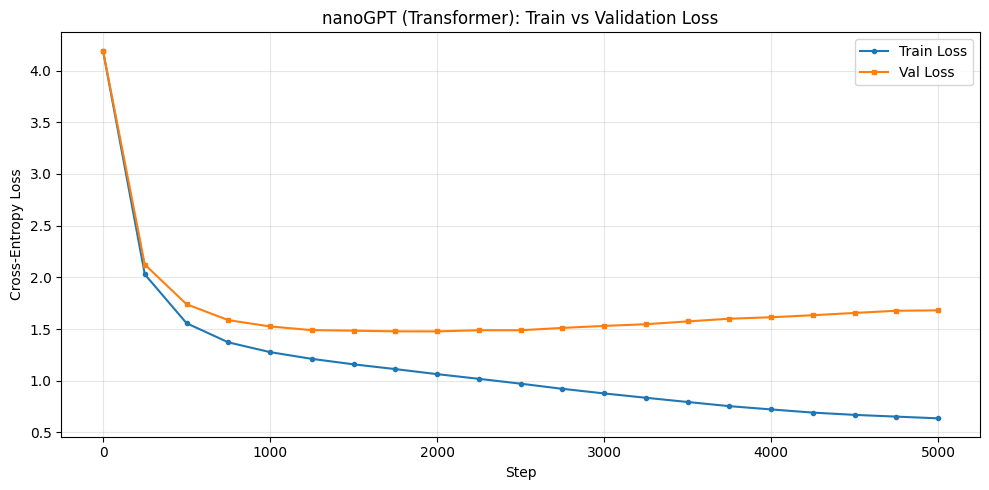

Final train loss: 0.6362
Final val loss:   1.6805
Gap (val - train): 1.0443


In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(gpt_eval_steps, gpt_train_losses, label='Train Loss', marker='o', markersize=3)
plt.plot(gpt_eval_steps, gpt_val_losses, label='Val Loss', marker='s', markersize=3)
plt.xlabel('Step')
plt.ylabel('Cross-Entropy Loss')
plt.title('nanoGPT (Transformer): Train vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

gap = gpt_val_losses[-1] - gpt_train_losses[-1]
print(f"Final train loss: {gpt_train_losses[-1]:.4f}")
print(f"Final val loss:   {gpt_val_losses[-1]:.4f}")
print(f"Gap (val - train): {gap:.4f}")

#### Sample poems from the trained nanoGPT

In [18]:
def gpt_generate_text(prompt, max_new_tokens=1000, temperature=0.8, top_k=200):
    """Generate text from the nanoGPT model given a string prompt."""
    gpt_model.eval()
    tokens = encode(prompt)
    x = torch.tensor(tokens, dtype=torch.long, device=DEVICE)[None, ...]
    with torch.no_grad():
        with ctx:
            y = gpt_model.generate(x, max_new_tokens, temperature=temperature, top_k=top_k)
    gpt_model.train()
    return decode(y[0].tolist())

print("=== nanoGPT (trained from scratch) — temperature 0.8 ===\n")
print(gpt_generate_text("ROMEO:\n", max_new_tokens=2000, temperature=0.8))

=== nanoGPT (trained from scratch) — temperature 0.8 ===

ROMEO:
Indeed, and I never in my life
Depart of his limits chance to a holy suit:
The third is not the man; he's a mad word, a touch,
A better fire, a better than a king.

PETRUCHIO:
Sir, understand for my maidenhead is set
On the beggar and discovery of the beast.

GRUMIO:

HORTENSIO:
Gramercy, king a  poor suitor, in your closet!
But of your own choice?

GREMIO:
I am too sorry too much for a maid: and the
sister is one require, as we should not know
How is ever as a thing imagine, to make him such a life:
and he is a mad of small carver take away.

GRUMIO:
No, sir; a wind of worm.

PETRUCHIO:
Signior Hortensio, faith, thou art widowed; and
you are day to give him an honest, as I am not
fellow that is for the volume of your age and your honour
accuse. But, prithee, she will be thine own to sever me and
that a man of the four-dish, the common matter for
men, which now, is in a man cock-rosement in the senate, a
bearing gentleman

---

## 3. Pretrained nanoGPT — Fine-tuned on Shakespeare

We load [sosier/nanoGPT-shakespeare-char-tied-weights](https://huggingface.co/sosier/nanoGPT-shakespeare-char-tied-weights), a **10.65M-parameter** character-level nanoGPT (6 layers, 6 heads, 384-dim, vocab=65) already trained on Shakespeare. We fine-tune it further and sample poems.


No `transformers` needed — just `tiktoken` and `torch`.

In [10]:
@dataclass
class PreGPTConfig:
    block_size: int = 256
    vocab_size: int = 65
    n_layer: int = 6
    n_head: int = 6
    n_embd: int = 384
    dropout: float = 0.2
    bias: bool = False

In [11]:
import urllib.request

class PreLayerNorm(nn.Module):
    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None
    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5)

class PreCausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.dropout = config.dropout
        self.flash = hasattr(torch.nn.functional, 'scaled_dot_product_attention')
        if not self.flash:
            self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                         .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        if self.flash:
            y = F.scaled_dot_product_attention(q, k, v, attn_mask=None,
                    dropout_p=self.dropout if self.training else 0, is_causal=True)
        else:
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y

class PreMLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x

class PreBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = PreLayerNorm(config.n_embd, bias=config.bias)
        self.attn = PreCausalSelfAttention(config)
        self.ln_2 = PreLayerNorm(config.n_embd, bias=config.bias)
        self.mlp = PreMLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

class PreGPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte=nn.Embedding(config.vocab_size, config.n_embd),
            wpe=nn.Embedding(config.block_size, config.n_embd),
            drop=nn.Dropout(config.dropout),
            h=nn.ModuleList([PreBlock(config) for _ in range(config.n_layer)]),
            ln_f=PreLayerNorm(config.n_embd, bias=config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight

    def forward(self, idx, targets=None):
        B, T = idx.size()
        assert T <= self.config.block_size
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)
        x = self.transformer.drop(self.transformer.wte(idx) + self.transformer.wpe(pos))
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        if targets is not None:
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
        else:
            logits = self.lm_head(x[:, [-1], :])
            loss = None
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

In [12]:
from huggingface_hub import hf_hub_download
import torch

torch.cuda.empty_cache()

ckpt_path = hf_hub_download(
    repo_id="Yi3852/nanogpt-270M",
    filename="pytorch_model.bin"   # this repo uses standard name
)

state_dict = torch.load(ckpt_path)

/home/dirakiza/miniconda3/envs/lstm-env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


RemoteEntryNotFoundError: 404 Client Error. (Request ID: Root=1-69a7ccfa-305c72dd7c8923bc120cca53;e24dacca-220c-4e89-8d18-1eb29bd8896b)

Entry Not Found for url: https://huggingface.co/Yi3852/nanogpt-270M/resolve/main/pytorch_model.bin.

In [23]:
pre_config = PreGPTConfig()
pre_model = PreGPT(pre_config)

pre_model.load_state_dict(state_dict, strict=False)

pre_model = pre_model.to(DEVICE)

print(f"Pretrained nanoGPT loaded: {sum(p.numel() for p in pre_model.parameters()):,} parameters")
print(f"Config: block_size={pre_config.block_size}, vocab_size={pre_config.vocab_size}, "
      f"n_layer={pre_config.n_layer}, n_head={pre_config.n_head}, n_embd={pre_config.n_embd}")

Pretrained nanoGPT loaded: 10,745,088 parameters
Config: block_size=256, vocab_size=65, n_layer=6, n_head=6, n_embd=384


In [ ]:
pre_sorted_chars = sorted(list(set(text)))
pre_stoi = {ch: i for i, ch in enumerate(pre_sorted_chars)}
pre_itos = {i: ch for i, ch in enumerate(pre_sorted_chars)}
pre_encode = lambda s: [pre_stoi[c] for c in s]
pre_decode = lambda l: ''.join([pre_itos[i] for i in l])
print(f"Char vocab: {len(pre_sorted_chars)} characters")

Char vocab: 65 characters


#### Sample from pretrained model (before fine-tuning)

Generate text with the pretrained checkpoint to see what it already knows — no additional training has been done yet.

In [30]:
from contextlib import nullcontext

device_type = 'cuda' if 'cuda' in DEVICE else 'cpu'
dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16'
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]
ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

def pre_generate(prompt, max_new_tokens=500, temperature=0.8, top_k=None):
    pre_model.eval()
    tokens = pre_encode(prompt)
    x = torch.tensor(tokens, dtype=torch.long, device=DEVICE)[None, ...]
    with torch.no_grad():
        with ctx:
            y = pre_model.generate(x, max_new_tokens, temperature=temperature, top_k=top_k)
    return pre_decode(y[0].tolist())

print("=== Pretrained nanoGPT — BEFORE fine-tuning ===\n")

print("--- Sample 1 (temperature 0.8, prompt: ROMEO) ---\n")
print(pre_generate("ROMEO:\n", max_new_tokens=1000, temperature=0.8, top_k=200))

print("\n--- Sample 2 (temperature 0.5, prompt: KING HENRY) ---\n")
print(pre_generate("KING HENRY:\n", max_new_tokens=1000, temperature=0.5, top_k=200))

print("\n--- Sample 3 (temperature 1.0, prompt: First Citizen) ---\n")
print(pre_generate("First Citizen:\nBefore we proceed any further, hear me speak.\n\n", max_new_tokens=1000, temperature=1.0))

=== Pretrained nanoGPT — BEFORE fine-tuning ===

--- Sample 1 (temperature 0.8, prompt: ROMEO) ---

ROMEO:
The matter; I am great dead upon thyself.

TRANIO:
Sir, I pray you, thee, sir, come again,
That I furn to to the unmarried throne.

CAMILLO:
Yes, how you are the most remedy, look you how?
Not therein out of me affection, so you think
you, you have made us like a word of death.

BENVOLIO:
The very well-coffer'd beloved in the life?

BENVOLIO:
Then, why, if he do last the end of spirit, he still make
put up down as a coward as a traitor for his work
assolve? as you shall be here so?

MERCUTIO:
A thousand times as else, the heavens cannot be
but a little mill tie that have been to left in
some other particular for can relate him to see: he
shall she be a sooner young and find-for the wounds
of her face are wondered: go with him, and he hath stood affected him his
the matter; and he will prove his son
cause of his death? He will have no sound in his potder
face whipped is so even upo

#### Fine-tune on Shakespeare

The model is already trained on Shakespeare, so fine-tuning here means continuing training for more iterations.

In [25]:
torch.cuda.empty_cache()

ft_block_size = 256
ft_batch_size = 64
ft_max_iters = 500
ft_learning_rate = 1e-4
ft_eval_interval = 50
ft_eval_iters = 20
ft_grad_clip = 1.0

device_type = 'cuda' if 'cuda' in DEVICE else 'cpu'
dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16'
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]
ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

ft_data = np.array(pre_encode(text), dtype=np.int64)
ft_n = len(ft_data)
ft_train = ft_data[:int(ft_n * 0.9)]
ft_val = ft_data[int(ft_n * 0.9):]
print(f"Fine-tune data: {ft_n:,} char tokens | train {len(ft_train):,} | val {len(ft_val):,}")

def ft_get_batch(split):
    data = ft_train if split == 'train' else ft_val
    ix = torch.randint(len(data) - ft_block_size, (ft_batch_size,))
    x = torch.stack([torch.from_numpy(data[i:i+ft_block_size].copy()) for i in ix])
    y = torch.stack([torch.from_numpy(data[i+1:i+1+ft_block_size].copy()) for i in ix])
    return x.to(DEVICE), y.to(DEVICE)

@torch.no_grad()
def ft_estimate_loss():
    out = {}
    pre_model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(ft_eval_iters)
        for k in range(ft_eval_iters):
            x, y = ft_get_batch(split)
            with ctx:
                _, loss = pre_model(x, y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    pre_model.train()
    return out

ft_optimizer = torch.optim.AdamW(pre_model.parameters(), lr=ft_learning_rate, weight_decay=0.01)

ft_train_losses = []
ft_val_losses = []
ft_steps = []
ft_best_val = 1e9

pre_model.train()
t0 = time.time()

for it in range(ft_max_iters + 1):
    if it % ft_eval_interval == 0:
        losses = ft_estimate_loss()
        ft_train_losses.append(losses['train'])
        ft_val_losses.append(losses['val'])
        ft_steps.append(it)
        marker = " *" if losses['val'] < ft_best_val else ""
        if losses['val'] < ft_best_val:
            ft_best_val = losses['val']
        print(f"step {it:4d} | train loss {losses['train']:.4f} | val loss {losses['val']:.4f}{marker}")

    x, y = ft_get_batch('train')
    with ctx:
        _, loss = pre_model(x, y)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(pre_model.parameters(), ft_grad_clip)
    ft_optimizer.step()
    ft_optimizer.zero_grad(set_to_none=True)
    t0 = time.time()

print(f"\nFine-tuning complete. Best val loss: {ft_best_val:.4f}")

Fine-tune data: 1,115,393 char tokens | train 1,003,853 | val 111,540
step    0 | train loss 1.1066 | val loss 1.4563 *
step   50 | train loss 1.0677 | val loss 1.4510 *
step  100 | train loss 1.0595 | val loss 1.4431 *
step  150 | train loss 1.0522 | val loss 1.4629
step  200 | train loss 1.0389 | val loss 1.4488
step  250 | train loss 1.0382 | val loss 1.4464
step  300 | train loss 1.0295 | val loss 1.4487
step  350 | train loss 1.0258 | val loss 1.4631
step  400 | train loss 1.0219 | val loss 1.4581
step  450 | train loss 1.0231 | val loss 1.4519
step  500 | train loss 1.0193 | val loss 1.4593

Fine-tuning complete. Best val loss: 1.4431


#### Fine-tuning loss curve

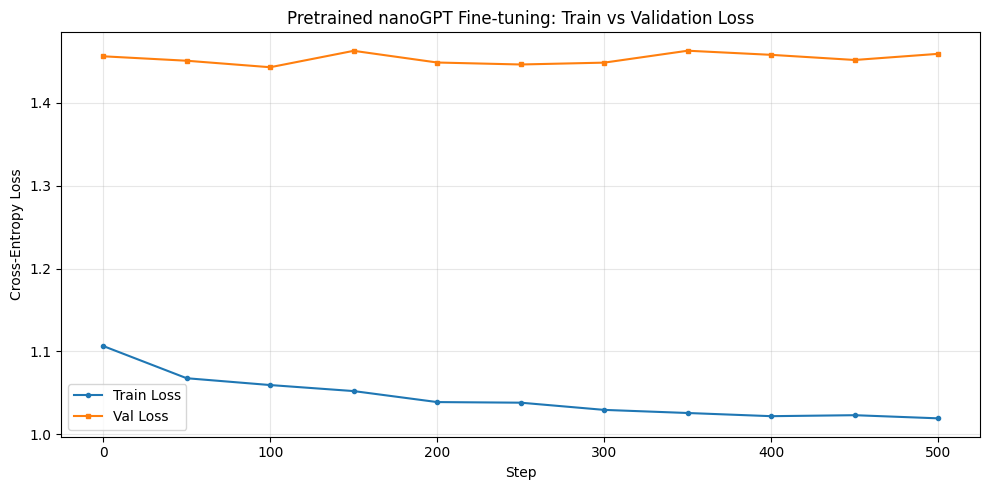

Final train loss: 1.0193
Final val loss:   1.4593


In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(ft_steps, ft_train_losses, label='Train Loss', marker='o', markersize=3)
plt.plot(ft_steps, ft_val_losses, label='Val Loss', marker='s', markersize=3)
plt.xlabel('Step')
plt.ylabel('Cross-Entropy Loss')
plt.title('Pretrained nanoGPT Fine-tuning: Train vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final train loss: {ft_train_losses[-1]:.4f}")
print(f"Final val loss:   {ft_val_losses[-1]:.4f}")

#### Sample poems from fine-tuned pretrained nanoGPT

In [28]:
def pre_generate(prompt, max_new_tokens=500, temperature=0.8, top_k=None):
    """Generate text from the fine-tuned pretrained nanoGPT."""
    pre_model.eval()
    tokens = pre_encode(prompt)
    x = torch.tensor(tokens, dtype=torch.long, device=DEVICE)[None, ...]
    with torch.no_grad():
        with ctx:
            y = pre_model.generate(x, max_new_tokens, temperature=temperature, top_k=top_k)
    return pre_decode(y[0].tolist())

print("=== Pretrained nanoGPT — Sample 1 (temperature 0.8) ===\n")
print(pre_generate("ROMEO:\n", max_new_tokens=2000, temperature=0.8, top_k=200))

=== Pretrained nanoGPT — Sample 1 (temperature 0.8) ===

ROMEO:
But love his life, and the letters on him.

ROMEO:
Then, be it set as he a fool: so fight
To seek upon him to friend; and from his house
Should not have his son of this seeming weary
With this liberal enemies, we would have held
The rest of monuments of his peace.

BENVOLIO:
Go you to him; then my good lord to your speech
That more in this life of it. Wherefore, I see,
The gods the house of York should be so so;
Let the should say 'Ay,' quoth my brother shall be found.'

GREMIO:
I am you agreed.

BENVOLIO:
O mother, I can do this person with sight:
Repent not and his passions of a rest.

BENVOLIO:
There is Abhorson can so other that I may call out;
And were passion of the return of this gentleman,
As I was not to come on.

ROMEO:
The great Romeo long-apparent! for in my lest
Invention of his presence, there's a merit in arms
To say 'Cominius,' and a wisely power,
That I have heard of said, and so teach entertain'd
With who

In [ ]:
print("=== Pretrained nanoGPT — Sample 2 (temperature 0.5) ===\n")
print(pre_generate("KING HENRY:\n", max_new_tokens=2000, temperature=0.5, top_k=200))

In [ ]:
print("=== Pretrained nanoGPT — Sample 3 (temperature 1.0) ===\n")
print(pre_generate("First Citizen:\nBefore we proceed any further, hear me speak.\n\n", max_new_tokens=2000, temperature=1.0))